## Logistic Regression 

Load up required libraries and dataset. Convert the data to a dataframe containing a subset of the data:

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pumpkins = pd.read_csv('US-pumpkins.csv')

In [7]:
pumpkins.columns

Index(['City Name', 'Type', 'Package', 'Variety', 'Sub Variety', 'Grade',
       'Date', 'Low Price', 'High Price', 'Mostly Low', 'Mostly High',
       'Origin', 'Origin District', 'Item Size', 'Color', 'Environment',
       'Unit of Sale', 'Quality', 'Condition', 'Appearance', 'Storage', 'Crop',
       'Repack', 'Trans Mode', 'Unnamed: 24', 'Unnamed: 25'],
      dtype='object')

In [3]:
pumpkins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1757 entries, 0 to 1756
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   City Name        1757 non-null   object 
 1   Type             45 non-null     object 
 2   Package          1757 non-null   object 
 3   Variety          1752 non-null   object 
 4   Sub Variety      296 non-null    object 
 5   Grade            0 non-null      float64
 6   Date             1757 non-null   object 
 7   Low Price        1757 non-null   float64
 8   High Price       1757 non-null   float64
 9   Mostly Low       1654 non-null   float64
 10  Mostly High      1654 non-null   float64
 11  Origin           1754 non-null   object 
 12  Origin District  131 non-null    object 
 13  Item Size        1478 non-null   object 
 14  Color            1141 non-null   object 
 15  Environment      0 non-null      float64
 16  Unit of Sale     162 non-null    object 
 17  Quality       

In [5]:
pumpkins.head(5)

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,4/29/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,5/6/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/5/16,90.0,100.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [ ]:
# Select the columns we want to use
wanted_cols = pumpkins[['City Name','Package','Variety', 'Item Size', 'Color','Origin']].copy()
#the rest is either null cols or not useful at all


# Drop rows with missing values
wanted_cols.dropna(inplace=True)


In [13]:
wanted_cols.head(5)

,City Name,Package,Variety,Item Size,Color,Origin
2,BALTIMORE,24 inch bins,HOWDEN TYPE,med,ORANGE,DELAWARE
3,BALTIMORE,24 inch bins,HOWDEN TYPE,med,ORANGE,VIRGINIA
4,BALTIMORE,24 inch bins,HOWDEN TYPE,lge,ORANGE,MARYLAND
5,BALTIMORE,24 inch bins,HOWDEN TYPE,lge,ORANGE,MARYLAND
6,BALTIMORE,36 inch bins,HOWDEN TYPE,med,ORANGE,MARYLAND


# Let's have a look to our data!

By visualising it with Seaborn

<Axes: xlabel='count', ylabel='Variety'>

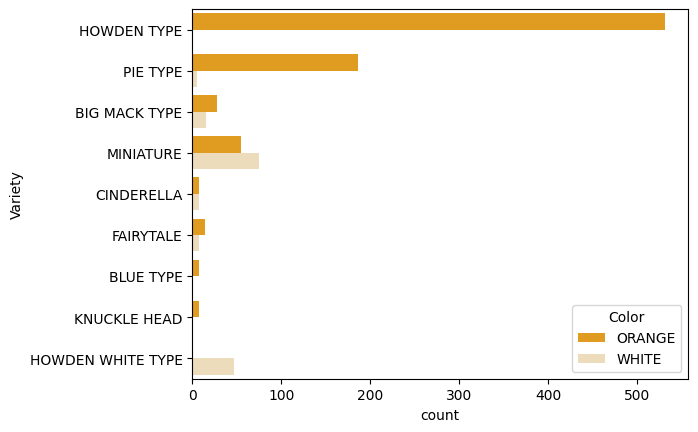

In [15]:
import seaborn as sns
# Specify colors for each values of the hue variable
palette = {
    'ORANGE': 'orange',
    'WHITE': 'wheat',
}

# Plot a bar plot to visualize how many pumpkins of each variety are orange or white
sns.countplot(
    data=wanted_cols,
    y='Variety',
    hue='Color',
    palette=palette
)


# Data pre-processing

Let's encode features and labels to better plot the data and train the model

In [32]:
# Let's look at the different values of the 'Item Size' column

itm_size_categs=wanted_cols['Item Size'].unique()
print(itm_size_categs)


['med' 'lge' 'sml' 'xlge' 'med-lge' 'jbo' 'exjbo']


In [38]:
from sklearn.preprocessing import OrdinalEncoder
# Encode the 'Item Size' column using ordinal encoding

ordinal_features=['Item Size'] # only col name not the data itself so it doesnt give error with columntransform
ordinal_encoder=OrdinalEncoder(categories=[itm_size_categs])


In [ ]:
from sklearn.preprocessing import OneHotEncoder
# Encode all the other features using one-hot encoding

categorical_features=['City Name','Package','Variety', 'Color','Origin']
categorical_encoder=OneHotEncoder(sparse_output=False)
#Spares عشان يفك ضغط البيانات اللي بيعمله الoneHotEncoder

In [57]:
from sklearn.compose import ColumnTransformer
#transforming data from regular values to the numeric values we just made
ct = ColumnTransformer(transformers=[
     ('ord', ordinal_encoder, ordinal_features),
     ('cat', categorical_encoder, categorical_features)
     ])
# Get the encoded features as a pandas DataFrame
All_encoded =pd.DataFrame(ct.fit_transform(wanted_cols))
All_encoded.head()

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [49]:
from sklearn.preprocessing import LabelEncoder
# Encode the 'Color' column using label encoding

# thats the target for me to predict
# عشان اعمل مابينج مابين الlabel encoder  و اللون اللي هعرف منه مين اخد قيمه 1 و مين 0  
#المفروض الاداه بتاعت الانكودر نفسها تبقا ف متغير لوحدها عشان اقارن بينها و بين الاصلي

color_feature =wanted_cols['Color']
label_encoder =LabelEncoder()
color_encoder =label_encoder.fit_transform(color_feature)



In [50]:
# Let's look at the mapping between the encoded values and the original values
color_mapping= dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(color_mapping)



{'ORANGE': np.int64(0), 'WHITE': np.int64(1)}


# Analysing relationships between features and label

C:\Users\Soft Key\AppData\Local\Temp\ipykernel_400\2745723277.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


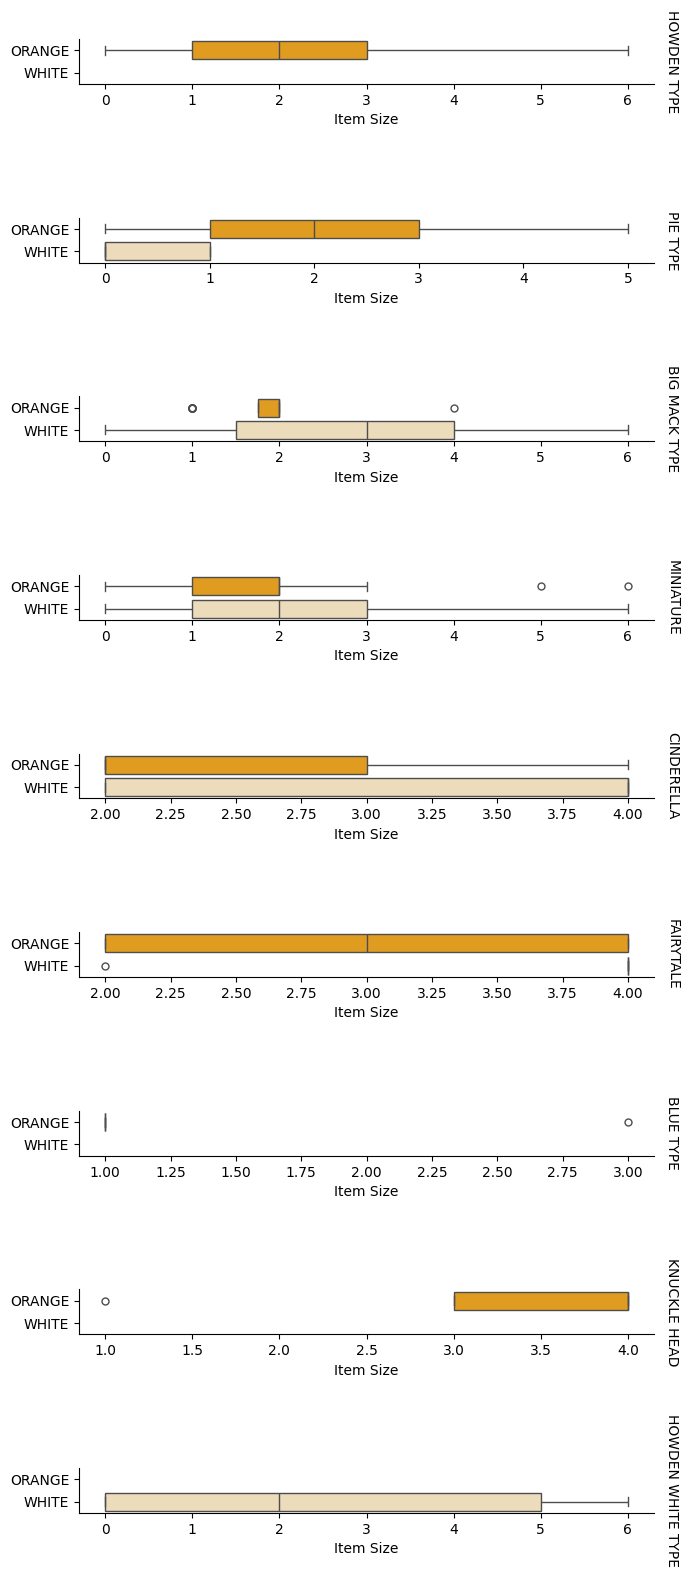

In [52]:
palette = {
    'ORANGE': 'orange',
    'WHITE': 'wheat',
}
# We need the encoded Item Size column to use it as the x-axis values in the plot

# Defining axis labels 

plot_data = wanted_cols.copy()
plot_data['Item Size'] = All_encoded[0] 

g = sns.catplot(
    data=plot_data,
    x="Item Size", 
    y="Color", 
    row="Variety",    
    kind="box",       
    orient="h",      
    sharex=False, 
    margin_titles=True,
    height=1.8, 
    aspect=4, 
    palette=palette
)

g.set(xlabel="Item Size", ylabel="")
g.set_titles(row_template="{row_name}")

plt.show()

Let's now focus on a specific relationship: Item Size and Color!

In [53]:
import warnings
warnings.filterwarnings(action='ignore', category=UserWarning, module='seaborn')

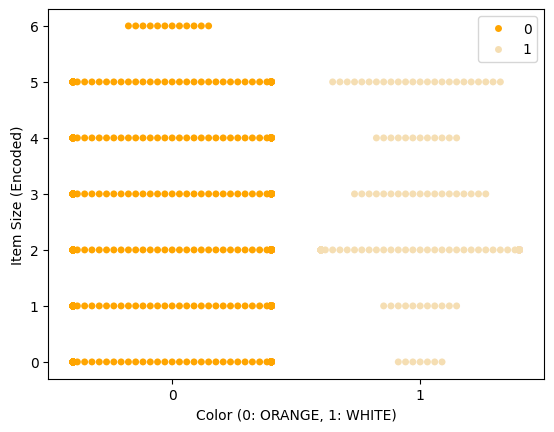

In [60]:
# Suppressing warning message claiming that a portion of points cannot be placed into the plot due to the high number of data points
import warnings
warnings.filterwarnings(action='ignore', category=UserWarning, module='seaborn')

palette = {
    0: 'orange',
    1: 'wheat'
}
sns.swarmplot(x=color_encoder, y=All_encoded[0], hue=color_encoder, data=All_encoded, palette=palette)

plt.xlabel("Color (0: ORANGE, 1: WHITE)")
plt.ylabel("Item Size (Encoded)")
plt.show()

**Watch out**: Ignoring warnings is NOT a best practice and should be avoid, whenever possible. Warnings often contain useful messages that let us improve our code and solve an issue.
The reason why we are ignoring this specific warning is to guarantee the readability of the plot. Plotting all the data points with a reduced marker size, while keeping consistency with the palette color, generates an unclear visualization.

# Build your model

In [61]:
from sklearn.model_selection import train_test_split
# X is the encoded features

X_train, X_test, y_train, y_test = train_test_split(All_encoded, color_encoder, test_size=0.2, random_state=0)

# y is the encoded label

# Split the data into training and test sets


In [63]:
from sklearn.metrics import f1_score, classification_report 
from sklearn.linear_model import LogisticRegression

# Train a logistic regression model on the pumpkin dataset
model=LogisticRegression()
model.fit(X_train,y_train)
prediction =model.predict(X_test)

# Evaluate the model and print the results
from sklearn.metrics import accuracy_score

print(f'accuracy:{accuracy_score(y_test, prediction):.2f}')
print(f'F1-Score: {f1_score(y_test, prediction):.2f}')


accuracy:1.00
F1-Score: 1.00


In [64]:
from sklearn.metrics import confusion_matrix


conf_matrix = confusion_matrix(y_test, prediction)
print("Confusion Matrix:\n", conf_matrix)

Confusion Matrix:
 [[166   0]
 [  0  33]]
